# Обучение модели ResNet18 для классификации AI vs Human Generated Images

Этот notebook содержит код для обучения модели ResNet18 на датасете Train_1 и оценки качества на Test_1.

## 1. Импорт библиотек

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import json
import pandas as pd
import numpy as np
from datetime import datetime
from pathlib import Path
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
import matplotlib.pyplot as plt

ARTIFACTS_DIR = Path('artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)
RUNS_DIR = Path('runs')
RUNS_DIR.mkdir(exist_ok=True)

training_params = {
    'experiment_name': 'baseline_train1',
    'model_name': 'resnet18',
    'pretrained': True,
    'num_classes': 2,
    'train_csv': 'ai-vs-human-generated-dataset-hw/Train_1/train.csv',
    'train_root': 'ai-vs-human-generated-dataset-hw/Train_1',
    'test_csv': 'ai-vs-human-generated-dataset-hw/Test_1/test.csv',
    'test_root': 'ai-vs-human-generated-dataset-hw/Test_1',
    'image_size': 224,
    'batch_size': 32,
    'num_epochs': 10,
    'optimizer': 'Adam',
    'learning_rate': 0.001,
    'scheduler': 'StepLR',
    'scheduler_step_size': 5,
    'scheduler_gamma': 0.1,
}

run_dir = RUNS_DIR / f"{training_params['experiment_name']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir.mkdir(parents=True, exist_ok=True)
with open(run_dir / 'params.json', 'w', encoding='utf-8') as params_file:
    json.dump(training_params, params_file, ensure_ascii=False, indent=2)

writer = SummaryWriter(log_dir=str(run_dir))
writer.add_text('params', json.dumps(training_params, ensure_ascii=False, indent=2))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Подготовка данных

In [13]:
class ImageDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.root_dir = Path(root_dir)
        self.transform = transform
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path = self.root_dir / self.data.iloc[idx]['file_name']
        image = Image.open(img_path).convert('RGB')
        label = int(self.data.iloc[idx]['label'])
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [14]:
train_transform = transforms.Compose([
    transforms.Resize((training_params['image_size'], training_params['image_size'])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((training_params['image_size'], training_params['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageDataset(
    csv_file=training_params['train_csv'],
    root_dir=training_params['train_root'],
    transform=train_transform
)

test_dataset = ImageDataset(
    csv_file=training_params['test_csv'],
    root_dir=training_params['test_root'],
    transform=test_transform
)

batch_size = training_params['batch_size']
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

print(f'Train dataset size: {len(train_dataset)}')
print(f'Test dataset size: {len(test_dataset)}')

Train dataset size: 9993
Test dataset size: 3997


## 3. Создание модели ResNet18

In [15]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

print(f'Model architecture:')
print(model)

Model architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): R

## 4. Определение функции потерь и оптимизатора

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=training_params['learning_rate'])
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=training_params['scheduler_step_size'],
    gamma=training_params['scheduler_gamma'],
)

## 5. Функция обучения

In [17]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for images, labels in tqdm(dataloader, desc='Training'):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='binary')
    
    return epoch_loss, epoch_acc, epoch_f1

## 6. Функция валидации

In [18]:
def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='binary')
    epoch_precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)
    epoch_recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)
    
    return epoch_loss, epoch_acc, epoch_f1, epoch_precision, epoch_recall

## 7. Обучение модели

In [19]:
num_epochs = training_params['num_epochs']
train_losses = []
train_accs = []
train_f1s = []

best_train_f1 = 0.0
best_model_path = ARTIFACTS_DIR / 'resnet18_train1_best.pt'

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    print('-' * 50)
    
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
    scheduler.step()
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_f1s.append(train_f1)
    writer.add_scalar('train/loss', train_loss, epoch + 1)
    writer.add_scalar('train/accuracy', train_acc, epoch + 1)
    writer.add_scalar('train/f1', train_f1, epoch + 1)
    writer.add_scalar('train/learning_rate', scheduler.get_last_lr()[0], epoch + 1)
    
    if train_f1 > best_train_f1:
        best_train_f1 = train_f1
        torch.save(model.state_dict(), best_model_path)
    
    print(f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}')

torch.save(model.state_dict(), ARTIFACTS_DIR / 'resnet18_train1_last.pt')
print('\nTraining completed!')
print(f'Best Train F1: {best_train_f1:.4f}')


Epoch 1/10
--------------------------------------------------


Training: 100%|██████████| 313/313 [00:18<00:00, 17.18it/s]


Train Loss: 0.3616, Acc: 0.8478, F1: 0.8466

Epoch 2/10
--------------------------------------------------


Training: 100%|██████████| 313/313 [00:17<00:00, 17.99it/s]


Train Loss: 0.2839, Acc: 0.8834, F1: 0.8831

Epoch 3/10
--------------------------------------------------


...

Train Loss: 0.0944, Acc: 0.9647, F1: 0.9646

Epoch 9/10
--------------------------------------------------


Training: 100%|██████████| 313/313 [00:18<00:00, 16.61it/s]


Train Loss: 0.0800, Acc: 0.9683, F1: 0.9683

Epoch 10/10
--------------------------------------------------


Training: 100%|██████████| 313/313 [00:18<00:00, 16.86it/s]

Train Loss: 0.0747, Acc: 0.9713, F1: 0.9712

Training completed!
Best Train F1: 0.9712


## 8. Оценка модели на тестовом датасете

Validation: 100%|██████████| 125/125 [00:06<00:00, 19.26it/s]


Test metrics on Test_1:
loss: 0.0886
accuracy: 0.9652
f1: 0.9654
precision: 0.9627
recall: 0.9680


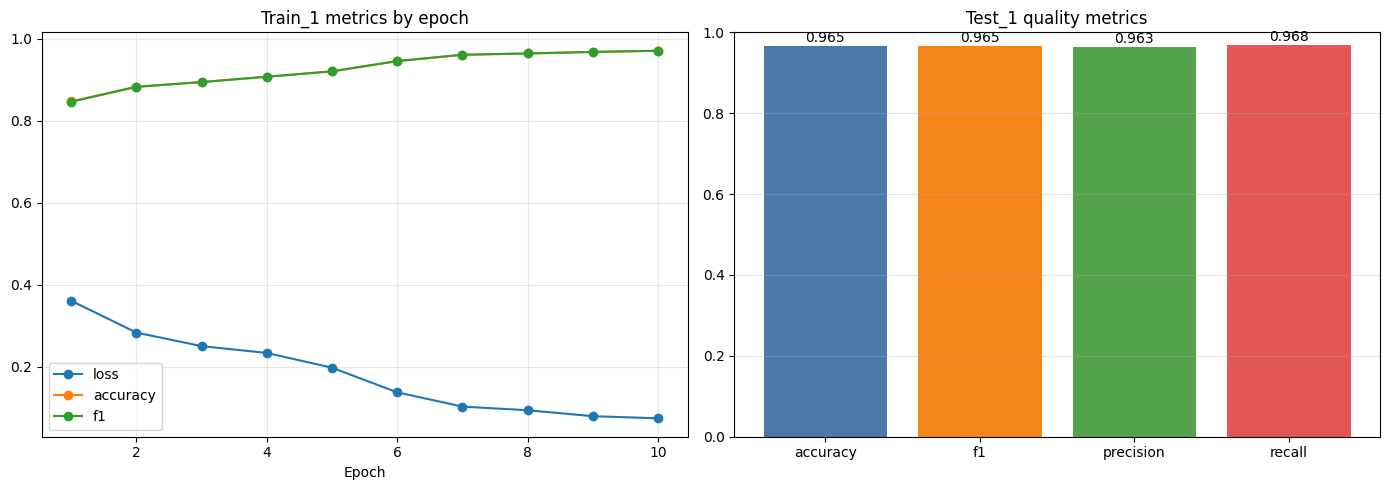

Train metrics saved to: artifacts/baseline_train1_train_metrics.csv
Test metrics saved to: artifacts/baseline_train1_test_metrics.json
Metrics plot saved to: artifacts/baseline_train1_metrics.png
TensorBoard logs saved to: runs/baseline_train1_20260522_211947


In [22]:
test_loss, test_acc, test_f1, test_precision, test_recall = validate(model, test_loader, criterion, device)

test_metrics = {
    'loss': test_loss,
    'accuracy': test_acc,
    'f1': test_f1,
    'precision': test_precision,
    'recall': test_recall,
}

print('Test metrics on Test_1:')
for metric_name, metric_value in test_metrics.items():
    writer.add_scalar(f'test/{metric_name}', metric_value, num_epochs)
    print(f'{metric_name}: {metric_value:.4f}')

train_metrics_df = pd.DataFrame({
    'epoch': list(range(1, num_epochs + 1)),
    'loss': train_losses,
    'accuracy': train_accs,
    'f1': train_f1s,
})
train_metrics_path = ARTIFACTS_DIR / 'baseline_train1_train_metrics.csv'
test_metrics_path = ARTIFACTS_DIR / 'baseline_train1_test_metrics.json'
metrics_plot_path = ARTIFACTS_DIR / 'baseline_train1_metrics.png'

train_metrics_df.to_csv(train_metrics_path, index=False)
with open(test_metrics_path, 'w', encoding='utf-8') as metrics_file:
    json.dump(test_metrics, metrics_file, ensure_ascii=False, indent=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_metrics_df['epoch'], train_metrics_df['loss'], marker='o', label='loss')
axes[0].plot(train_metrics_df['epoch'], train_metrics_df['accuracy'], marker='o', label='accuracy')
axes[0].plot(train_metrics_df['epoch'], train_metrics_df['f1'], marker='o', label='f1')
axes[0].set_title('Train_1 metrics by epoch')
axes[0].set_xlabel('Epoch')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

bar_metrics = ['accuracy', 'f1', 'precision', 'recall']
axes[1].bar(bar_metrics, [test_metrics[name] for name in bar_metrics], color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])
axes[1].set_ylim(0, 1)
axes[1].set_title('Test_1 quality metrics')
axes[1].grid(True, axis='y', alpha=0.3)
for index, metric_name in enumerate(bar_metrics):
    axes[1].text(index, test_metrics[metric_name] + 0.01, f"{test_metrics[metric_name]:.3f}", ha='center')

plt.tight_layout()
fig.savefig(metrics_plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Train metrics saved to: {train_metrics_path}')
print(f'Test metrics saved to: {test_metrics_path}')
print(f'Metrics plot saved to: {metrics_plot_path}')

writer.add_hparams(
    {key: str(value) for key, value in training_params.items()},
    {f'hparam/test_{key}': value for key, value in test_metrics.items()},
)
writer.flush()
writer.close()
print(f'TensorBoard logs saved to: {run_dir}')

## 8.1. Загрузка модели в S3 / MinIO

In [23]:
from minio import Minio
from minio.error import S3Error

s3_config = {
    'endpoint': 'localhost:19000',
    'access_key': 'minioadmin',
    'secret_key': 'minioadmin',
    'secure': False,
    'bucket_name': 'mlops-models',
    'object_name': 'baseline/resnet18_train1_best.pt',
}

model_artifact_path = ARTIFACTS_DIR / 'resnet18_train1_best.pt'
if not model_artifact_path.exists():
    raise FileNotFoundError(f'Model artifact not found: {model_artifact_path}')

client = Minio(
    s3_config['endpoint'],
    access_key=s3_config['access_key'],
    secret_key=s3_config['secret_key'],
    secure=s3_config['secure'],
)

try:
    if not client.bucket_exists(s3_config['bucket_name']):
        client.make_bucket(s3_config['bucket_name'])

    upload_result = client.fput_object(
        s3_config['bucket_name'],
        s3_config['object_name'],
        str(model_artifact_path),
        content_type='application/octet-stream',
    )

    s3_upload_info = {
        'bucket': s3_config['bucket_name'],
        'object': s3_config['object_name'],
        'etag': upload_result.etag,
        'version_id': upload_result.version_id,
        'source_file': str(model_artifact_path),
        'source_size_bytes': model_artifact_path.stat().st_size,
        'console_url': 'http://localhost:19001',
    }
    s3_upload_info_path = ARTIFACTS_DIR / 'baseline_train1_s3_upload.json'
    with open(s3_upload_info_path, 'w', encoding='utf-8') as upload_file:
        json.dump(s3_upload_info, upload_file, ensure_ascii=False, indent=2)

    print('Model artifact uploaded to MinIO')
    print(f"s3://{s3_upload_info['bucket']}/{s3_upload_info['object']}")
    print(f'Upload info saved to: {s3_upload_info_path}')
except S3Error as exc:
    raise RuntimeError(
        'MinIO upload failed. Check that local MinIO is running on http://localhost:19000 '
        'with login/password minioadmin/minioadmin.'
    ) from exc

Model artifact uploaded to MinIO
s3://mlops-models/baseline/resnet18_train1_best.pt
Upload info saved to: artifacts/baseline_train1_s3_upload.json


## 9. Дообучите модель на втором датасете и постройте DVC пайплайн

In [21]:
# Добавьте логику дообучения
# Добавьте PVC пайплайн

## 10. Напишите вывод о полученных результатах

Базовая ResNet18 после обучения на Train_1 показала хорошее качество на Test_1: accuracy = 0.9652, F1 = 0.9654, precision = 0.9627, recall = 0.9680. Метрики обучения и теста сохранены в TensorBoard (`runs/baseline_train1_20260522_211947`), а дополнительно результаты лежат в `artifacts/baseline_train1_train_metrics.csv`, `artifacts/baseline_train1_test_metrics.json` и на графике `artifacts/baseline_train1_metrics.png`. Обученный артефакт модели также загружен в локальный S3/MinIO: `s3://mlops-models/baseline/resnet18_train1_best.pt`, подтверждение сохранено в `artifacts/baseline_train1_s3_upload.json`. Для первого бейзлайна результат выглядит нормальным: качество на тесте высокое, сильного провала относительно train-метрик не видно, дальше эту модель можно использовать как стартовую точку для дообучения на Train_2.